# Geographically Weighted Principal Components Analysis (GWPCA)

`spatialml` implements `GWPCA` to perform spatially localized Principal Components Analysis. Unlike standard global PCA which computes a single set of principal components for the entire dataset, GWPCA computes unique principal components around every focal observation based on a local spatial neighborhood.

## Setup and Data
We will use the Guerry dataset (historical French census data) to demonstrate GWPCA.

In [ ]:
import sys
import os

sys.path.insert(0, os.path.abspath("."))

import sys
import os

# Todo: remove these once published.
sys.path.insert(0, os.path.abspath("../libpysal"))
sys.path.insert(0, os.path.abspath("."))

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from geodatasets import get_path

from sklearn.decomposition import PCA
from spatialml.decomposition import GWPCA
from sklearn.preprocessing import StandardScaler

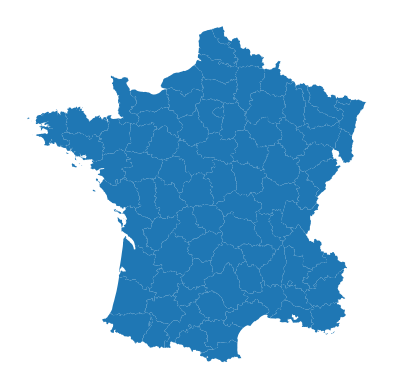

In [ ]:
# Testing with the Guerry dataset - standardizing it as per Harris et al. (2011)
gdf = gpd.read_file(get_path("geoda.guerry"))
gdf.plot().set_axis_off()

Selecting a few socio-demographic variables to extract principal components from.

In [ ]:
variables = ["Crm_prs", "Litercy", "Wealth", "Donatns", "Infants"]
X = gdf[variables]

# standardization
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)

## 1. Global PCA
First, let's see what global PCA gives us across the entire country of France.

In [5]:
global_pca = PCA(n_components=2)
global_pca.fit(X_scaled)

print("Global PCA Explained Variance Ratio:")
print(global_pca.explained_variance_ratio_)

print("\nGlobal PCA Components:")
print(pd.DataFrame(global_pca.components_, columns=X.columns, index=["PC1", "PC2"]))

Global PCA Explained Variance Ratio:
[0.35715985 0.22827994]

Global PCA Components:
      Crm_prs   Litercy    Wealth   Donatns   Infants
PC1 -0.031997 -0.557519  0.499685  0.325421  0.576684
PC2  0.790855 -0.073221 -0.297212  0.525816 -0.066095


## 2. GWPCA
Now, we apply `GWPCA` using an adaptive bandwidth of 25 nearest neighbors. Notice that `fit_transform` will return the local components for each area.

In [6]:
gwpca = GWPCA(n_components=2, bandwidth=25, fixed=False, kernel="bisquare")

local_scores = gwpca.fit_transform(X=X_scaled, geometry=gdf.centroid)

# The components are stored locally per observation
print(
    f"Shape of local components array: {gwpca.components_.shape} (n_samples, n_components, n_features)"
)

Shape of local components array: (85, 5, 2) (n_samples, n_components, n_features)


Because the components are local, we can extract and visualize the percentage of variance explained by PC1 across the different regions.

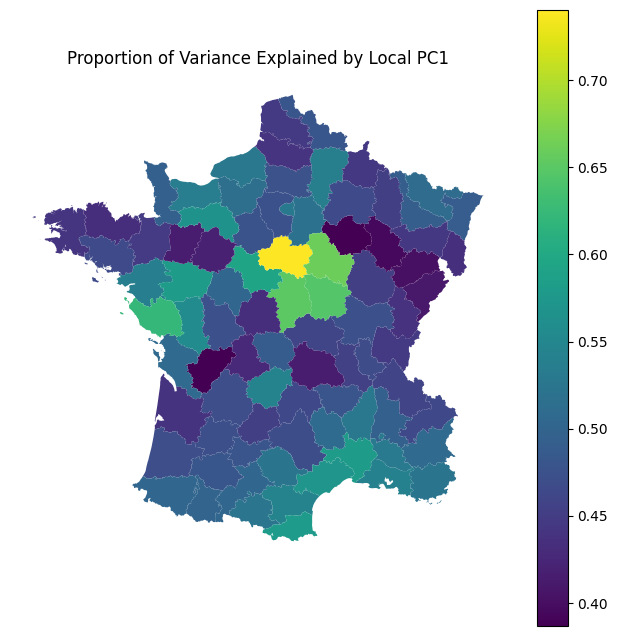

In [7]:
# Extract variance explained by the first component (PC1)
gdf["local_var_pc1"] = gwpca.explained_variance_ratio_[:, 0]

# Plot the geographical distribution of PC1's variance ratio
fig, ax = plt.subplots(figsize=(8, 8))
gdf.plot(column="local_var_pc1", cmap="viridis", legend=True, ax=ax)
ax.set_title("Proportion of Variance Explained by Local PC1")
ax.set_axis_off()
plt.show()

And we can also visualize how the influence (loading) of a specific feature, like `Wealth`, on PC1 varies spatially.

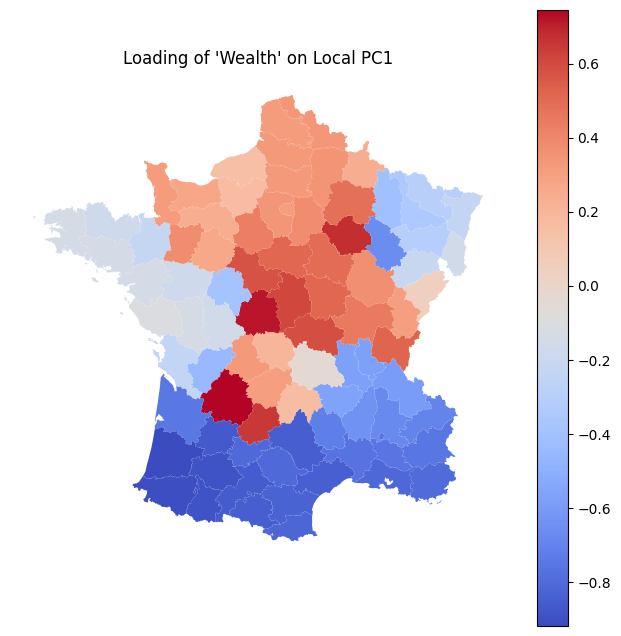

In [ ]:
# Extract the loading of the "Wealth" variable (index 2) onto PC1 (index 0) for all observations
gdf["local_wealth_pc1"] = gwpca.components_[:, 2, 0]


# Plot the geographical distribution
fig, ax = plt.subplots(figsize=(8, 8))
gdf.plot(column="local_wealth_pc1", cmap="coolwarm", legend=True, ax=ax)
ax.set_title("Loading of 'Wealth' on Local PC1")
ax.set_axis_off()
plt.show()